In [1]:
import yaml
from pathlib import Path
import geopandas as gpd
import pandas as pd
from shapely.geometry import box
import numpy as np
from pprint import pprint

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/Gates Foundation/Building Dataset Validation")
CONFIG_PATH = PROJECT_ROOT / "configs/validation_config_juba.yaml"
# CONFIG_PATH = PROJECT_ROOT / "configs/validation_config_curacao.yaml"
print("CONFIG_PATH =", CONFIG_PATH)

with open(CONFIG_PATH, "r") as f:
    validation_config = yaml.safe_load(f)

pprint(validation_config)

CONFIG_PATH = /content/drive/MyDrive/Gates Foundation/Building Dataset Validation/configs/validation_config_juba.yaml
{'aoi': 'data/01_raw/uga-nakamiro/aoi/nakamiro_aoi.geojson',
 'city': 'uga-nakamiro',
 'crs': 'EPSG:32636',
 'reference': 'data/01_raw/uga-nakamiro/vector/nakamiro_hotosm.geojson',
 'root_dir': '/content/drive/MyDrive/Gates Foundation/Building Dataset '
             'Validation',
 'vector': {'datasets': [{'enabled': True, 'name': 'overture'},
                         {'enabled': True, 'name': 'gba'},
                         {'enabled': True, 'name': 'globfp'}],
            'out_path': 'data/01_raw/uga-nakamiro/vector/',
            'preprocessing': {'fix_invalid_geoms': True,
                              'min_area_m2': 20,
                              'tau_boundary': 2.0,
                              'tau_buffer_m': 2.0,
                              'tau_overlap': 0.5,
                              'tile_size_m': 1000}}}


In [4]:
import os 
os.chdir(PROJECT_ROOT)

In [5]:
from src.utils import load_aoi, make_tiles, load_buildings, subset_by_tile
from src.metrics import compute_tile_metrics

In [6]:
ROOT = (PROJECT_ROOT / validation_config["root_dir"]).resolve()
CITY = validation_config["city"]

aoi = load_aoi(path=validation_config["aoi"], crs_out=validation_config["crs"])
tiles = make_tiles(aoi, validation_config["vector"]["preprocessing"]["tile_size_m"])


# Save to 02_interim so we can reuse the tiling later
tiles_path = ROOT / f"data/02_interim/tiles/{CITY.lower()}_tiles.gpkg"
tiles_path.parent.mkdir(parents=True, exist_ok=True)
tiles.to_file(tiles_path, driver="GPKG")
tiles.head()

,tile_id,geometry
0,0,"POLYGON ((450893.214 38156.457, 450893.214 391..."
1,1,"POLYGON ((450893.214 39156.457, 450893.214 401..."
2,2,"POLYGON ((450893.214 40156.457, 450893.214 411..."
3,3,"POLYGON ((450893.214 41156.457, 450893.214 421..."
4,4,"POLYGON ((450893.214 42156.457, 450893.214 431..."


In [7]:
validation_config["vector"]["preprocessing"]["tile_size_m"]

1000

In [8]:
# Load reference and make spatial index once
# Load reference and make spatial index once
ref_all = load_buildings(
    path=PROJECT_ROOT/validation_config["reference"],
    crs_work=validation_config["crs"],
    min_area_m2=validation_config["vector"]["preprocessing"]["min_area_m2"],
    fix_invalid_geoms=True,
)
ref_all_sindex = ref_all.sindex

print("Reference buildings:", len(ref_all))

Reference buildings: 37279


In [9]:
CANDIDATES = validation_config["vector"]["datasets"]
TAU_OVERLAP= validation_config["vector"]["preprocessing"]["tau_overlap"]
TAU_BUFFER_M = validation_config["vector"]["preprocessing"]["tau_buffer_m"]
TAU_BOUNDARY_M = validation_config["vector"]["preprocessing"]["tau_boundary"]

# Ensure outputs folder
metrics_dir = ROOT / f"outputs/metrics/{CITY.lower()}"
metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir = ROOT / f"outputs/figures/{CITY.lower()}"
figures_dir.mkdir(parents=True, exist_ok=True)

all_tile_metrics = []
all_match_rows = []

for cand_cfg in CANDIDATES:
    # city_name = "ssd_juba"
    city_name = "uga_nakamiro"
    ds_name = cand_cfg["name"]
    # candidate data may not exist yet; use glob to locate files and
    # handle the case where none are present.
    data_dir = ROOT / validation_config["vector"]["out_path"]
    pattern = f"{city_name}_{ds_name}*.parquet"
    matches = list(data_dir.glob(pattern))
    if not matches:
        print(f"Warning: no candidate files found for dataset '{ds_name}' (looking for {pattern} in {data_dir}). Skipping.")
        continue

    # choose the first matching path (adjust logic if multiple files expected)
    cand_path = matches[0]

    print(f"\n=== Dataset: {ds_name} ===")
    cand_all = load_buildings(path = cand_path,
                          crs_work = validation_config["crs"], 
                          min_area_m2= validation_config["vector"]["preprocessing"]["min_area_m2"],
                          fix_invalid_geoms = True)
    cand_all_sindex = cand_all.sindex
    print("Candidate buildings:", len(cand_all))

    ds_tile_metrics = []
    ds_match_rows = []

    for _, tile_row in tiles.iterrows():
        tile_geom = tile_row.geometry
        tile_id = int(tile_row["tile_id"])

        ref_tile = subset_by_tile(ref_all, ref_all_sindex, tile_geom)
        cand_tile = subset_by_tile(cand_all, cand_all_sindex, tile_geom)

        if ref_tile.empty and cand_tile.empty:
            continue

        metrics, matches_df = compute_tile_metrics(
            ref_tile, CITY, cand_tile, TAU_OVERLAP, TAU_BUFFER_M, TAU_BOUNDARY_M, tile_id, ds_name
        )
        ds_tile_metrics.append(metrics)

        if not matches_df.empty:
            # Attach context info (city, dataset, tile_id)
            matches_df = matches_df.copy()
            matches_df["city"] = CITY
            matches_df["dataset"] = ds_name
            matches_df["tile_id"] = tile_id
            ds_match_rows.append(matches_df)

    # Save per-dataset tile metrics
    ds_tile_df = pd.DataFrame(ds_tile_metrics)
    tile_out_path = metrics_dir / f"vector_metrics_tiles_{ds_name}.parquet"
    ds_tile_df.to_parquet(tile_out_path, index=False)
    print(f"Saved tile metrics for {ds_name} → {tile_out_path}")

    # Save per-dataset matches
    if ds_match_rows:
        ds_matches_df = pd.concat(ds_match_rows, ignore_index=True)
        match_out_path = metrics_dir / f"vector_matches_{ds_name}.parquet"
        ds_matches_df.to_parquet(match_out_path, index=False)
        print(f"Saved building matches for {ds_name} → {match_out_path}")
    else:
        ds_matches_df = pd.DataFrame(columns=["ref_id", "cand_id", "iou", "area_ref", "area_cand", "rel_area_error", "city", "dataset", "tile_id"])

    all_tile_metrics.append(ds_tile_df)
    all_match_rows.append(ds_matches_df)

# Optional: combined city-wide dataframes
if all_tile_metrics:
    metrics_all = pd.concat(all_tile_metrics, ignore_index=True)
    metrics_all.to_parquet(metrics_dir / "vector_metrics_tiles_all_datasets.parquet", index=False)
    display(metrics_all.head())

if all_match_rows:
    matches_all = pd.concat(all_match_rows, ignore_index=True)
    matches_all.to_parquet(metrics_dir / "vector_matches_all_datasets.parquet", index=False)
    display(matches_all.head())


=== Dataset: overture ===
Candidate buildings: 27595
Saved tile metrics for overture → /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics/uga-nakamiro/vector_metrics_tiles_overture.parquet
Saved building matches for overture → /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics/uga-nakamiro/vector_matches_overture.parquet

=== Dataset: gba ===
Candidate buildings: 28046
Saved tile metrics for gba → /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics/uga-nakamiro/vector_metrics_tiles_gba.parquet
Saved building matches for gba → /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics/uga-nakamiro/vector_matches_gba.parquet

=== Dataset: globfp ===
Candidate buildings:

,city,dataset,tile_id,n_ref,n_cand,tp,fp,fn,precision,recall,...,median_iou,iou_p25,iou_p75,boundary_f_union,boundary_f_meanpair,mean_rel_area_error,signed_area_bias,tau_overlap,tau_buffer_m,tau_boundary_m
0,uga-nakamiro,overture,0,2907,1684,1606,78,1301,0.953682,0.552460,...,1.0,1.0,1.0,0.999444,0.999473,-1.408778e-04,-0.000219,0.5,2.0,2.0
1,uga-nakamiro,overture,1,4072,1583,1523,60,2549,0.962097,0.374018,...,1.0,1.0,1.0,0.999091,0.999078,-6.712469e-04,-0.000663,0.5,2.0,2.0
2,uga-nakamiro,overture,2,3732,2268,2165,103,1567,0.954586,0.580118,...,1.0,1.0,1.0,0.998913,0.999238,9.654494e-04,0.000779,0.5,2.0,2.0
3,uga-nakamiro,overture,3,3516,2501,2344,157,1172,0.937225,0.666667,...,1.0,1.0,1.0,0.999721,0.999658,-2.501035e-04,-0.000282,0.5,2.0,2.0
4,uga-nakamiro,overture,4,318,5,5,0,313,1.000000,0.015723,...,1.0,1.0,1.0,1.000000,1.000000,4.059502e-17,0.000000,0.5,2.0,2.0


,ref_id,cand_id,iou,area_ref,area_cand,rel_area_error,boundary_f_pair,city,dataset,tile_id
0,20150,4498,1.0,53.312273,53.312273,-1.332794e-16,1.0,uga-nakamiro,overture,0
1,20032,2338,1.0,77.525793,77.525793,1.833049e-16,1.0,uga-nakamiro,overture,0
2,695,1624,1.0,126.707740,126.707740,0.000000e+00,1.0,uga-nakamiro,overture,0
3,20056,3078,1.0,48.479451,48.479451,0.000000e+00,1.0,uga-nakamiro,overture,0
4,14127,4302,1.0,54.459096,54.459096,1.304727e-16,1.0,uga-nakamiro,overture,0


In [10]:
from src.output import summarize_city 
# reporting: city-level summaries
metrics_all_path = metrics_dir / "vector_metrics_tiles_all_datasets.parquet"
matches_all_path = metrics_dir / "vector_matches_all_datasets.parquet"

metrics_all = pd.read_parquet(metrics_all_path) if metrics_all_path.exists() else pd.DataFrame()
matches_all = pd.read_parquet(matches_all_path) if matches_all_path.exists() else pd.DataFrame()

if not metrics_all.empty:
    city_summary = summarize_city(CITY, metrics_all, matches_all)
    summary_path = metrics_dir / "vector_city_summary_all_datasets.parquet"
    city_summary.to_parquet(summary_path, index=False)
    display(city_summary)

    # Also save CSV for quick sharing
    city_summary.to_csv(metrics_dir / "vector_city_summary_all_datasets.csv", index=False)
    print("Saved:", summary_path)

,city,dataset,n_sub_areas,n_tiles,n_ref_total,n_cand_total,tp_total,fp_total,fn_total,precision_city,recall_city,f1_city,iou_mean_tp,iou_median_tp,iou_p25_tp,iou_p75_tp,boundary_f_meanpair_tp,rel_area_error_mean_tp,rel_area_error_median_tp,signed_area_bias_tp
0,uga-nakamiro,gba,1,14,37872,28704,20824,7880,17048,0.7255,0.5499,0.6256,0.7229,0.7251,0.6431,0.7976,0.8956,0.1400,0.0794,0.0936
1,uga-nakamiro,globfp,1,14,37872,28789,20349,8440,17523,0.7068,0.5373,0.6105,0.7125,0.7191,0.6391,0.7889,0.8921,0.1449,0.0882,0.0953
2,uga-nakamiro,overture,1,14,37872,28217,26741,1476,11131,0.9477,0.7061,0.8092,0.9994,1.0000,1.0000,1.0000,0.9997,0.0000,0.0000,-0.0001


Saved: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics/uga-nakamiro/vector_city_summary_all_datasets.parquet


## Visualization

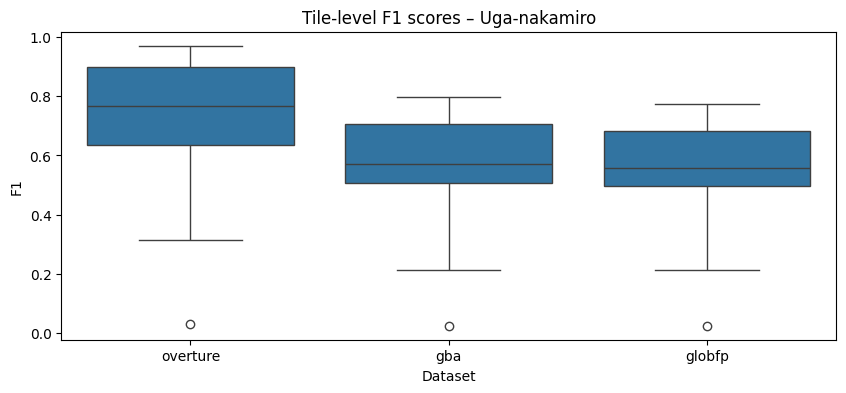

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from src.output import save_figure, fig_name

metrics_all = pd.read_parquet(metrics_dir / "vector_metrics_tiles_all_datasets.parquet")

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=metrics_all, x="dataset", y="f1", ax=ax)

ax.set_title(f"Tile-level F1 scores – {CITY.capitalize()}")
ax.set_xlabel("Dataset")
ax.set_ylabel("F1")

figures_dir = Path(PROJECT_ROOT) / "outputs" / "figures" / CITY
save_figure(fig, figures_dir, fig_name(CITY, "tile_f1_boxplot"))

plt.show()

Datasets found: ['overture' 'gba' 'globfp']


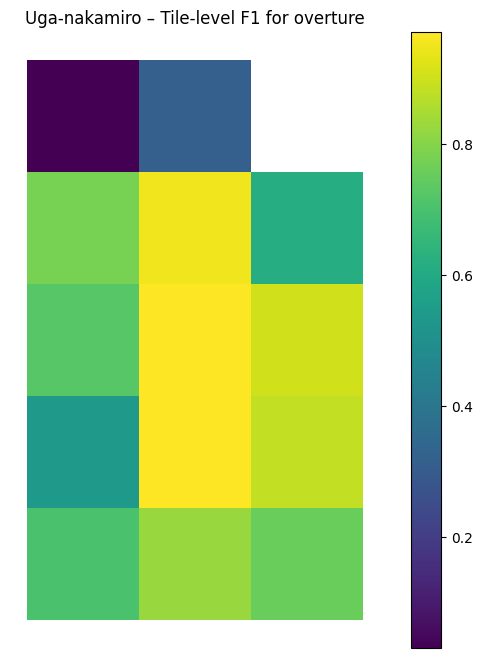

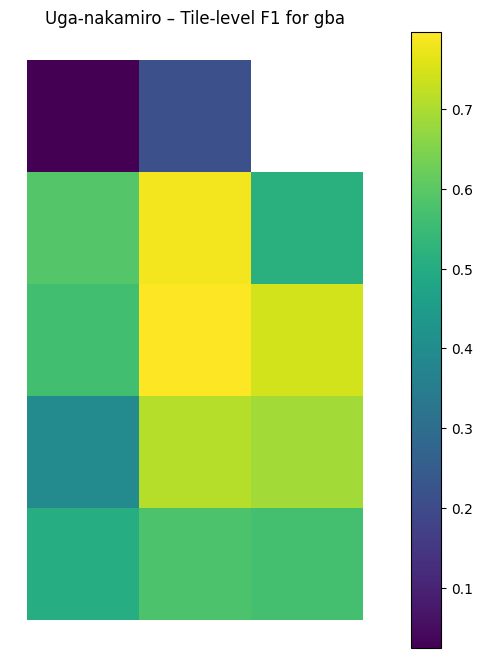

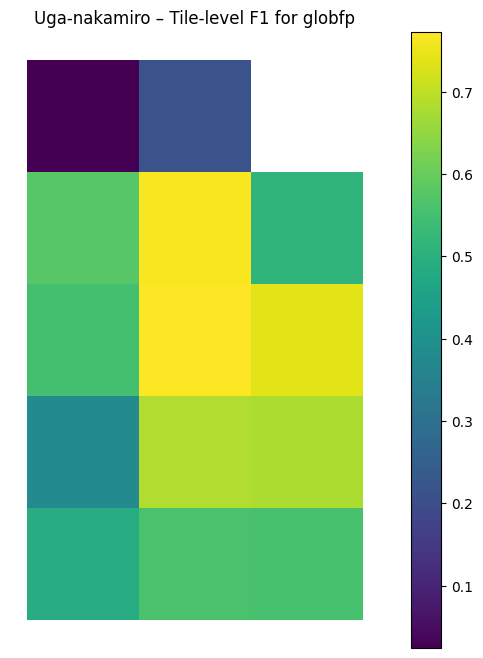

In [12]:
import matplotlib.pyplot as plt

# Load tiles and metrics
tiles_path = ROOT / f"data/02_interim/tiles/{CITY.lower()}_tiles.gpkg"
tiles = gpd.read_file(tiles_path)

metrics_all = pd.read_parquet(metrics_dir / "vector_metrics_tiles_all_datasets.parquet")

# Get the list of datasets present in the metrics table
datasets = metrics_all["dataset"].unique()
print("Datasets found:", datasets)

for ds_to_plot in datasets:
    # Filter metrics for this dataset
    metrics_ds = metrics_all[metrics_all["dataset"] == ds_to_plot]

    if metrics_ds.empty:
        print(f"Skipping {ds_to_plot}: no metrics available.")
        continue

    # Join F1 to tiles
    tiles_metrics = tiles.merge(
        metrics_ds[["tile_id", "f1"]],
        on="tile_id",
        how="left"
    )

    # Plot tile-level F1 for this dataset
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    tiles_metrics.plot(
        column="f1",
        ax=ax,
        legend=True,
        cmap="viridis",
        edgecolor="none"
    )
    ax.set_title(f"{CITY.capitalize()} – Tile-level F1 for {ds_to_plot}")
    ax.set_axis_off()

    save_figure(fig, figures_dir, fig_name(CITY, f"{CITY.capitalize()} – Tile-level F1 for {ds_to_plot}"))

    plt.show()

Datasets found: ['overture' 'gba' 'globfp'] 

=== Uga-nakamiro — overture ===
TP: 26,741  FP: 1,476  FN: 11,131
TP-only IoU mean: 0.999  (n=26,741)
All buildings (TP + FP + FN→0) IoU mean: 0.679  (n=39,348)


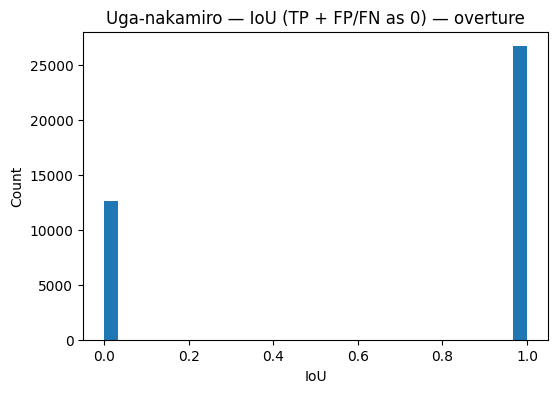


=== Uga-nakamiro — gba ===
TP: 20,824  FP: 7,880  FN: 17,048
TP-only IoU mean: 0.723  (n=20,824)
All buildings (TP + FP + FN→0) IoU mean: 0.329  (n=45,752)


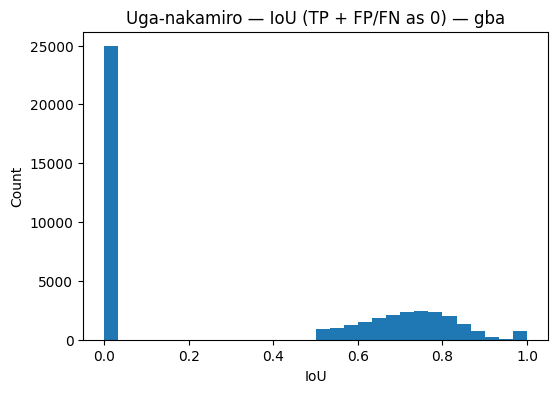


=== Uga-nakamiro — globfp ===
TP: 20,349  FP: 8,440  FN: 17,523
TP-only IoU mean: 0.713  (n=20,349)
All buildings (TP + FP + FN→0) IoU mean: 0.313  (n=46,312)


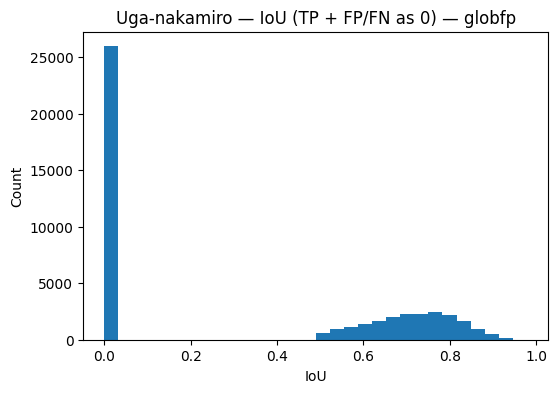

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load metrics + matches
metrics_all = pd.read_parquet(metrics_dir / "vector_metrics_tiles_all_datasets.parquet")
matches_all = pd.read_parquet(metrics_dir / "vector_matches_all_datasets.parquet")

datasets = metrics_all["dataset"].unique()
print("Datasets found:", datasets, "\n")

for ds_to_plot in datasets:
    print(f"=== {CITY.capitalize()} — {ds_to_plot} ===")

    # --- Tile-level TP / FP / FN totals ---
    m_ds = metrics_all[metrics_all["dataset"] == ds_to_plot]

    tp = m_ds["tp"].sum()
    fp = m_ds["fp"].sum()
    fn = m_ds["fn"].sum()

    print(f"TP: {tp:,}  FP: {fp:,}  FN: {fn:,}")

    # --- IoU for TP matches only ---
    ious_tp = matches_all[matches_all["dataset"] == ds_to_plot]["iou"].dropna()

    # --- Add zeros for FP + FN to approximate 'all buildings' view ---
    num_zeros = fp + fn
    ious_all = pd.concat(
        [ious_tp, pd.Series(np.zeros(num_zeros))],
        ignore_index=True
    )

    print(f"TP-only IoU mean: {ious_tp.mean():.3f}  (n={len(ious_tp):,})")
    print(f"All buildings (TP + FP + FN→0) IoU mean: {ious_all.mean():.3f}  (n={len(ious_all):,})")

    # --- Plot histogram ---
    plt.figure(figsize=(6, 4))
    plt.hist(ious_all, bins=30)
    plt.title(f"{CITY.capitalize()} — IoU (TP + FP/FN as 0) — {ds_to_plot}")
    plt.xlabel("IoU")
    plt.ylabel("Count")
    plt.show()

    print()  # spacing between datasets

Datasets found: ['overture' 'gba' 'globfp']

=== Uga-nakamiro — overture ===


,size_bin,mean_iou,median_iou,median_rel_area_error,count
0,<25,1.000000,1.0,0.0,2269
1,25–50,0.999415,1.0,0.0,8687
2,50–100,0.999412,1.0,0.0,9090
3,100–500,0.998939,1.0,0.0,6490
4,500–1000,1.000000,1.0,0.0,150
5,>1000,1.000000,1.0,0.0,55


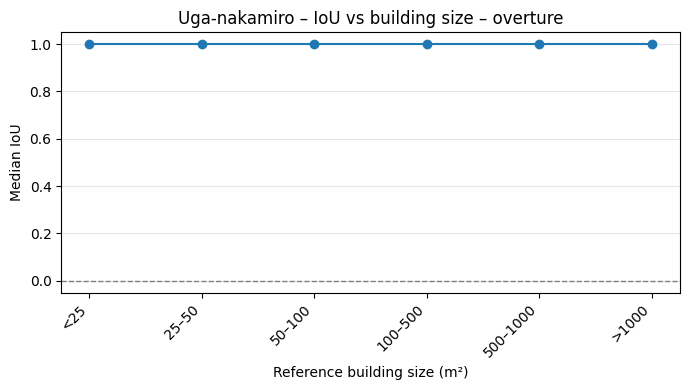

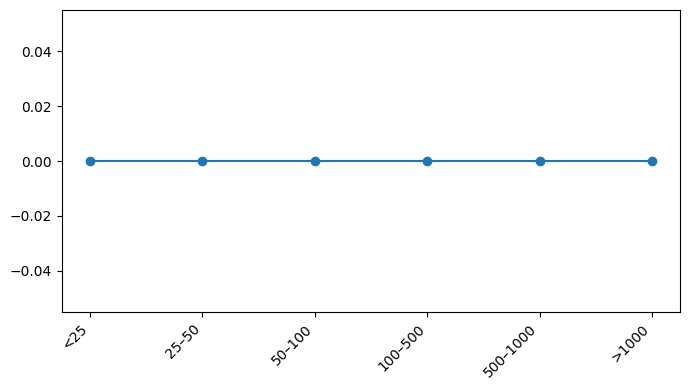


=== Uga-nakamiro — gba ===


,size_bin,mean_iou,median_iou,median_rel_area_error,count
0,<25,0.707015,0.677319,0.193889,1200
1,25–50,0.701901,0.691320,0.128788,6046
2,50–100,0.719481,0.724461,0.082383,7623
3,100–500,0.751244,0.767272,0.048354,5807
4,500–1000,0.762567,0.785576,0.033607,103
5,>1000,0.818576,0.852059,-0.000985,45


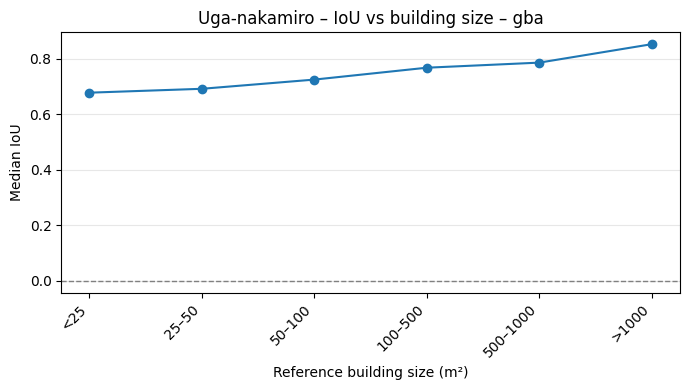

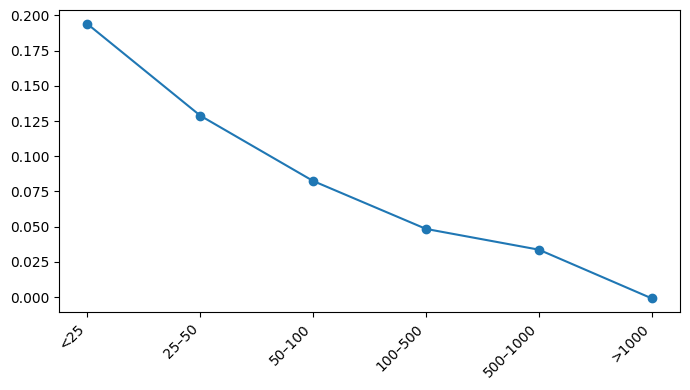


=== Uga-nakamiro — globfp ===


,size_bin,mean_iou,median_iou,median_rel_area_error,count
0,<25,0.663770,0.660124,0.265031,1082
1,25–50,0.683025,0.682098,0.150440,5843
2,50–100,0.713475,0.721215,0.087480,7516
3,100–500,0.748625,0.766149,0.049860,5761
4,500–1000,0.762567,0.785576,0.033607,103
5,>1000,0.814453,0.841533,-0.001179,44


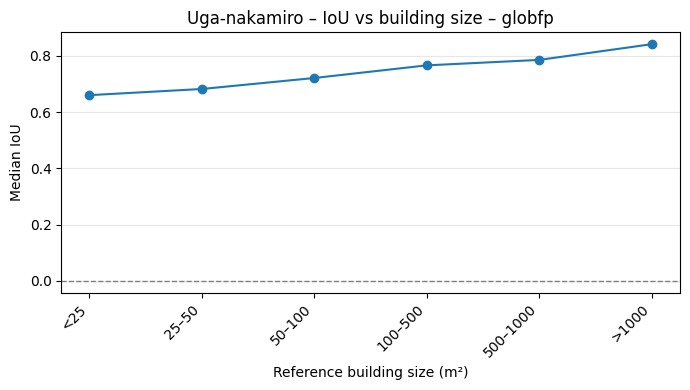

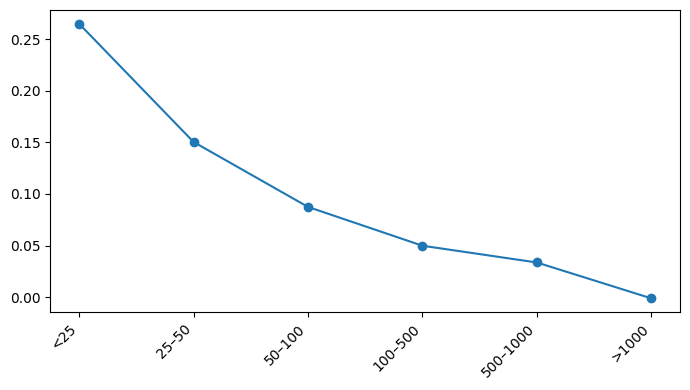

In [14]:
# ---------------- USER SETTINGS ----------------
USE_EXPLICIT_BINS = True   # set to False to use quantile bins

# Explicit bins (used if USE_EXPLICIT_BINS=True)
size_bins = [0, 25, 50, 100, 500, 1000, np.inf] # 5 hist-equalize results in 25, 33, 46, 74, 8584 for Juba
size_bin_labels = [
    "<25",
    "25–50",
    "50–100",
    "100–500",
    "500–1000",
    ">1000"
]

# Quantile bins (used if USE_EXPLICIT_BINS=False)
n_bins = 5
# ------------------------------------------------

matches_all = pd.read_parquet(metrics_dir / "vector_matches_all_datasets.parquet")

datasets = matches_all["dataset"].unique()
print("Datasets found:", datasets)

for ds in datasets:
    print(f"\n=== {CITY.capitalize()} — {ds} ===")

    m_ds = matches_all[matches_all["dataset"] == ds].copy()

    if m_ds.empty:
        print("No matched buildings for this dataset.")
        continue

    # ---- Define building size bins ----
    if USE_EXPLICIT_BINS:
        m_ds["size_bin"] = pd.cut(
            m_ds["area_ref"],
            bins=size_bins,
            labels=size_bin_labels,
            include_lowest=True
        )
    else:
        m_ds["size_bin"] = pd.qcut(
            m_ds["area_ref"],
            q=n_bins,
            duplicates="drop"
        )

    # ---- Aggregate statistics per size bin ----
    size_stats = (
        m_ds
        .groupby("size_bin", observed=True)
        .agg(
            mean_iou=("iou", "mean"),
            median_iou=("iou", "median"),
            median_rel_area_error=("rel_area_error", "median"),
            count=("iou", "size")
        )
        .reset_index()
    )

    display(size_stats)

    # ---- Plot: IoU vs building size ----
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        size_stats["size_bin"].astype(str),
        size_stats["median_iou"],
        marker="o"
    )
    plt.xticks(rotation=45, ha="right")
    for label in ax.get_xticklabels():
      label.set_ha("right")
    ax.set_ylabel("Median IoU")
    ax.set_xlabel("Reference building size (m²)")
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"{CITY.capitalize()} – IoU vs building size – {ds}")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()

    save_figure(fig, figures_dir, fig_name(CITY, f"{CITY.capitalize()} – IoU vs building size – {ds}"))

    plt.show()
    plt.close(fig)

    # ---- Plot: Relative area error vs building size ----
    fig = plt.figure(figsize=(7, 4))
    plt.plot(
        size_stats["size_bin"].astype(str),
        size_stats["median_rel_area_error"],
        marker="o"
    )
    plt.xticks(rotation=45, ha="right")
    ax.set_ylabel("Median relative area error")
    ax.set_xlabel("Reference building size (m²)")
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"{CITY.capitalize()} – Relative area error vs building size – {ds}")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()

    save_figure(fig, figures_dir, fig_name(CITY, f"{CITY.capitalize()} – Relative area error vs building size – {ds}"))

    plt.show()